# Model Training

## Set Up and Libraries

In [1]:
import os

# Switch Directories for Google Colab
if os.getcwd() == '/content':
    from google.colab import drive
    drive.mount('/content/drive')
    os.chdir("/content/drive/Othercomputers/My MacBook Pro/CreditCardFraudDetection/notebooks")

print(os.getcwd())

Mounted at /content/drive
/content/drive/Othercomputers/My MacBook Pro/CreditCardFraudDetection/notebooks


In [2]:
import sys
import numpy as np
import pickle
import joblib

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), os.pardir)))
from src import plot_confusion_matrix

## Logistic Regression

In [ ]:
# Load the preprocessed data
with open('../data/preprocessed_data.pkl', 'rb') as f:
    data = pickle.load(f)
    X_train = data['X_train']
    X_test = data['X_test']
    y_train = data['y_train']
    y_test = data['y_test']

print("Data loaded from preprocessed_data.pkl")

Data loaded from preprocessed_data.pkl


In [ ]:
# Apply Logistic Regression Model
lg = LogisticRegression(solver='liblinear')

# Search for the best class weight instead of forcing 'balanced'
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'class_weight': [None, {0: 1, 1: 5}, {0: 1, 1: 10}, {0: 1, 1: 15}]
}

grid_search = GridSearchCV(estimator=lg, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Get the best model and predict
best_model = grid_search.best_estimator_
y_test_pred = best_model.predict(X_test)

print("Best parameters found:", grid_search.best_params_)

Best parameters found: {'C': 10, 'class_weight': {0: 1, 1: 5}, 'penalty': 'l1'}


In [ ]:
# Evaluate the base logistic regression model on the testing set
print("Test evaluation - accuracy: {:.3f}, f1: {:.3f}, recall: {:.3f}, precision: {:.3f}"
    .format(accuracy_score(y_test, y_test_pred),
            f1_score(y_test, y_test_pred),
            recall_score(y_test, y_test_pred),
            precision_score(y_test, y_test_pred)))

Test evaluation - accuracy: 0.780, f1: 0.157, recall: 0.596, precision: 0.090


In [ ]:
# Try different predicting thresholds
y_probs = best_model.predict_proba(X_test)[:, 1]
for i in range(0, 11):
  threshold = i / 10
  y_pred_tresh = (y_probs >= threshold).astype(int)
  print("Test evaluation (threshold: {:.1f}) - accuracy: {:.3f}, f1: {:.3f}, recall: {:.3f}, precision: {:.3f}"
      .format(threshold,
              accuracy_score(y_test, y_pred_tresh),
              f1_score(y_test, y_pred_tresh),
              recall_score(y_test, y_pred_tresh),
              precision_score(y_test, y_pred_tresh)))

print("\nThe best threshold that fits the project goals is 0.4")
y_pred_tresh = (y_probs >= 0.4).astype(int)
print("Test evaluation (threshold: 0.4) - accuracy: {:.3f}, f1: {:.3f}, recall: {:.3f}, precision: {:.3f}"
    .format(accuracy_score(y_test, y_pred_tresh),
            f1_score(y_test, y_pred_tresh),
            recall_score(y_test, y_pred_tresh),
            precision_score(y_test, y_pred_tresh)))

# Test evaluation (threshold: 0.4) - accuracy: 0.663, f1: 0.125, recall: 0.699, precision: 0.068

Test evaluation (threshold: 0.0) - accuracy: 0.034, f1: 0.066, recall: 1.000, precision: 0.034
Test evaluation (threshold: 0.1) - accuracy: 0.155, f1: 0.073, recall: 0.975, precision: 0.038
Test evaluation (threshold: 0.2) - accuracy: 0.366, f1: 0.089, recall: 0.903, precision: 0.047
Test evaluation (threshold: 0.3) - accuracy: 0.537, f1: 0.106, recall: 0.799, precision: 0.057
Test evaluation (threshold: 0.4) - accuracy: 0.663, f1: 0.125, recall: 0.699, precision: 0.068
Test evaluation (threshold: 0.5) - accuracy: 0.780, f1: 0.157, recall: 0.596, precision: 0.090
Test evaluation (threshold: 0.6) - accuracy: 0.871, f1: 0.207, recall: 0.491, precision: 0.132
Test evaluation (threshold: 0.7) - accuracy: 0.920, f1: 0.252, recall: 0.391, precision: 0.186
Test evaluation (threshold: 0.8) - accuracy: 0.949, f1: 0.288, recall: 0.298, precision: 0.279
Test evaluation (threshold: 0.9) - accuracy: 0.964, f1: 0.273, recall: 0.194, precision: 0.458
Test evaluation (threshold: 1.0) - accuracy: 0.966

In [ ]:
# Save the model
joblib.dump(grid_search, '../models/lg.pkl')

# Save the best parameters to a text file
with open('../models/lg_best_params.txt', 'w') as f:
    f.write(str(grid_search.best_params_))

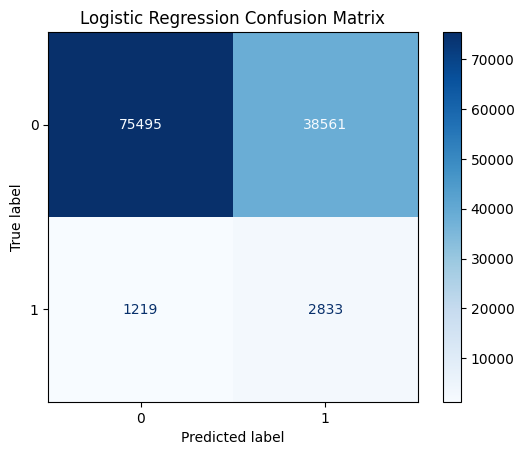

In [3]:
# Plot the Confusion Matrix Based on the Previously Trained Model
# Load the preprocessed data (X_test, y_test)
with open('../data/preprocessed_data.pkl', 'rb') as f:
    data = pickle.load(f)
    X_test = data['X_test']
    y_test = data['y_test']

# Load the Logistic Regression model
lg_grid_search = joblib.load('../models/lg.pkl')
best_lg_model = lg_grid_search.best_estimator_

# Load the best parameters
with open('../models/lg_best_params.txt', 'r') as f:
    best_lg_params_str = f.read()
    # Convert string representation of dict to actual dict
    best_lg_params = eval(best_lg_params_str)

# Prediction threshold
lg_threshold = 0.4

# Predict probabilities and apply threshold
y_probs_lg = best_lg_model.predict_proba(X_test)[:, 1]
y_pred_lg = (y_probs_lg >= lg_threshold).astype(int)

# Plot Confusion Matrix
plot_confusion_matrix(y_test, y_pred_lg, 'Logistic Regression Confusion Matrix', 'lg')

## K-Means

In [4]:
# Load the preprocessed data
with open('../data/preprocessed_data.pkl', 'rb') as f:
    data = pickle.load(f)
    X_train = data['X_train']
    X_test = data['X_test']
    y_train = data['y_train']
    y_test = data['y_test']

print("Data loaded from preprocessed_data.pkl")

Data loaded from preprocessed_data.pkl


In [5]:
# Hyperparameter search space
n_clusters_list = [2, 8, 20, 50, 70, 100]
batch_sizes = [2560, 5120, 10240, 20480]
percentiles = [90, 92, 95, 96.5, 98, 99]

best_f1 = 0
best_params = {}

print("Compare Different Hyperparameter Models")

for k in n_clusters_list:
    for batch in batch_sizes:
        # Train K-Means (Unsupervised)
        kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=batch, n_init='auto')
        kmeans.fit(X_train)

        # Get Anomaly Scores (Distances to closest cluster)
        X_test_distances = kmeans.transform(X_test)
        anomaly_scores = np.min(X_test_distances, axis=1)

        # Test different percentile thresholds
        for p in percentiles:
            threshold = np.percentile(anomaly_scores, p)
            y_pred_k_means = (anomaly_scores >= threshold).astype(int)

            # Evaluate using F1 Score and others
            f1 = f1_score(y_test, y_pred_k_means)
            acc = accuracy_score(y_test, y_pred_k_means)
            rec = recall_score(y_test, y_pred_k_means)
            prec = precision_score(y_test, y_pred_k_means)

            # Keep the best-performing model based on F1-score
            if f1 > best_f1:
                best_f1 = f1
                best_params = {'n_clusters': k, 'batch_size': batch, 'percentile': p}

            # Print each Model
            print(f"k={k}, batch={batch}, percentile={p} -> Acc: {acc:.4f}, F1: {f1:.4f}, Rec: {rec:.4f}, Prec: {prec:.4f}")

# Find the best model based on F1-Score and then compare with other values manually
print("\nCompare evaluations based on F1-Score and then manually with other values")
print(f"Best F1 Score: {best_f1:.4f} happens w/ Parameters: {best_params}")

# After Manual Comparison with other Values, the following hyperparameters suit the project the best
# k=70, batch=5120, percentile=92 -> Acc: 0.9062, F1: 0.1792, Rec: 0.2986, Prec: 0.1281
best_params = {'n_clusters': 70, 'batch_size': 5120, 'percentile': 92}
print("After manual selection, the following suits the project the best: " +
      "k=70, batch=5120, percentile=92 -> Acc: 0.9062, F1: 0.1792, Rec: 0.2986, Prec: 0.1281")

Compare Different Hyperparameter Models
k=2, batch=2560, percentile=90 -> Acc: 0.8872, F1: 0.1599, Rec: 0.3129, Prec: 0.1074
k=2, batch=2560, percentile=92 -> Acc: 0.9047, F1: 0.1665, Rec: 0.2774, Prec: 0.1190
k=2, batch=2560, percentile=95 -> Acc: 0.9303, F1: 0.1731, Rec: 0.2127, Prec: 0.1460
k=2, batch=2560, percentile=96.5 -> Acc: 0.9417, F1: 0.1583, Rec: 0.1599, Prec: 0.1567
k=2, batch=2560, percentile=98 -> Acc: 0.9528, F1: 0.1313, Rec: 0.1039, Prec: 0.1782
k=2, batch=2560, percentile=99 -> Acc: 0.9593, F1: 0.0822, Rec: 0.0531, Prec: 0.1819
k=2, batch=5120, percentile=90 -> Acc: 0.8871, F1: 0.1596, Rec: 0.3124, Prec: 0.1072
k=2, batch=5120, percentile=92 -> Acc: 0.9047, F1: 0.1665, Rec: 0.2774, Prec: 0.1190
k=2, batch=5120, percentile=95 -> Acc: 0.9303, F1: 0.1731, Rec: 0.2127, Prec: 0.1460
k=2, batch=5120, percentile=96.5 -> Acc: 0.9416, F1: 0.1581, Rec: 0.1597, Prec: 0.1565
k=2, batch=5120, percentile=98 -> Acc: 0.9528, F1: 0.1313, Rec: 0.1039, Prec: 0.1782
k=2, batch=5120, perc

In [6]:
# Train the Best K-Means Model
kmeans = MiniBatchKMeans(n_clusters=best_params["n_clusters"], random_state=42, batch_size=best_params["batch_size"], n_init='auto')
kmeans.fit(X_train)

# Anomaly Scores
X_test_distances = kmeans.transform(X_test)
anomaly_scores = np.min(X_test_distances, axis=1)

# Percentile threshold
threshold = np.percentile(anomaly_scores, best_params["percentile"])
y_pred_k_means = (anomaly_scores >= threshold).astype(int)

# Evaluate the Model
print("Test evaluation (K-Means w/ k={:.0f}, b={:.0f}, p={:.0f}) - acc: {:.3f}, f1: {:.3f}, rec: {:.3f}, prec: {:.3f}"
    .format(best_params["n_clusters"],
            best_params["batch_size"],
            best_params["percentile"],
            accuracy_score(y_test, y_pred_k_means),
            f1_score(y_test, y_pred_k_means),
            recall_score(y_test, y_pred_k_means),
            precision_score(y_test, y_pred_k_means)))

Test evaluation (K-Means w/ k=70, b=5120, p=92) - acc: 0.906, f1: 0.179, rec: 0.299, prec: 0.128


In [7]:
# Save the model
joblib.dump(kmeans, '../models/km.pkl')

# Save the best parameters to a text file
with open('../models/km_best_params.txt', 'w') as f:
    f.write(str(best_params))

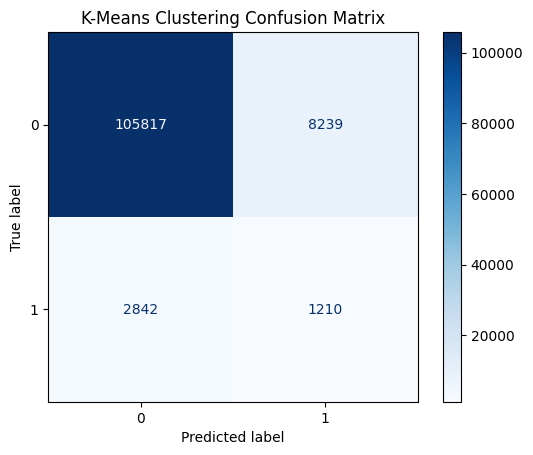

In [8]:
# Plot the confusion matrix
k_means_threshold = np.percentile(anomaly_scores, best_params["percentile"])
y_pred_k_means = (anomaly_scores >= k_means_threshold).astype(int)
plot_confusion_matrix(y_test, y_pred_k_means, 'K-Means Clustering Confusion Matrix', 'km')